Positive ratio and c

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_experiment import load_experiment_results 
import datetime 
from helpers import get_n_labels


In [3]:
EXPERIMENT = "positive_ratio_c"
VAR_1 = "positive_ratio"
VAR_2 = "c"

In [4]:
df = load_experiment_results(name=EXPERIMENT)
df = df[df["model"]!="oracle"]
df.columns

Index(['positive_ratio', 'c', 'dataset', 'iter', 'model', 'accuracy',
       '0 precision', '1 precision', '0 recall', '1 recall', '0 f1', '1 f1',
       '0 support', '1 support', 'c log'],
      dtype='object')

In [5]:
df["precision"] = (df["0 precision"]+df["1 precision"]) / 2
df["recall"] = (df["0 recall"]+df["1 recall"]) / 2
df["f1"] = (df["0 f1"]+df["1 f1"]) / 2

df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(4)
df[["precision","recall","f1"]].describe()

,precision,recall,f1
count,4800.000000,4800.000000,4800.000000
mean,0.728978,0.730933,0.693767
std,0.276340,0.271363,0.289134
min,0.000000,0.000000,0.000000
25%,0.635150,0.641950,0.564825
50%,0.786200,0.755350,0.717600
75%,0.950000,0.962950,0.954100
max,1.000000,1.000000,1.000000


In [6]:
fig_experiment_folder = EXPERIMENT
os.makedirs(fig_experiment_folder, exist_ok=True)
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
fig_folder = os.path.join(fig_experiment_folder, f"{current_time}")
os.makedirs(fig_folder, exist_ok=True)

In [7]:
df["c log"].unique()

array([0.183, 0.   ])

In [8]:
df.columns

Index(['positive_ratio', 'c', 'dataset', 'iter', 'model', 'accuracy',
       '0 precision', '1 precision', '0 recall', '1 recall', '0 f1', '1 f1',
       '0 support', '1 support', 'c log', 'precision', 'recall', 'f1'],
      dtype='object')

In [ ]:
# experiments = df[VAR_1].unique()
# experiments = [val for val in experiments if val.split("_")[1] == "1"]
# df_exp = df[df[VAR_1].isin(experiments)]
# df = df_exp


In [9]:
group_columns = [VAR_1, VAR_2, "model","dataset"]
data_G = df.groupby(group_columns).mean().reset_index()
data_G


,positive_ratio,c,model,dataset,iter,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,1 f1,0 support,1 support,c log,precision,recall,f1
0,0.1,0.005,classic,breastcancer,4.5,0.967391,0.985825,0.813333,0.978571,0.850000,0.982040,0.820317,42.0,4.0,0.183,0.89958,0.91429,0.90118
1,0.1,0.005,classic,diabetes,4.5,0.900000,0.900811,0.000000,0.999000,0.000000,0.947366,0.000000,100.0,11.0,0.183,0.45045,0.49950,0.47365
2,0.1,0.005,classic,mnist,4.5,0.977943,0.992882,0.856918,0.982557,0.936235,0.987685,0.894369,1481.5,164.2,0.183,0.92488,0.95938,0.94103
3,0.1,0.005,classic,mock,4.5,0.902777,0.902777,0.000000,1.000000,0.000000,0.948905,0.000000,195.0,21.0,0.183,0.45140,0.50000,0.47448
4,0.1,0.005,naive,breastcancer,4.5,0.604348,1.000000,0.182203,0.566667,1.000000,0.721738,0.307796,42.0,4.0,0.183,0.59110,0.78332,0.51477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,0.5,1.000,naive,mock,4.5,0.701172,0.717365,0.784684,0.849170,0.479231,0.741576,0.556437,195.0,130.0,0.183,0.75102,0.66420,0.64902
476,0.5,1.000,two_model,breastcancer,4.5,0.939286,0.920603,0.963132,0.964286,0.914286,0.941170,0.937160,42.0,42.0,0.183,0.94186,0.93930,0.93919
477,0.5,1.000,two_model,diabetes,4.5,0.727922,0.839909,0.589259,0.721000,0.740741,0.774663,0.654509,100.0,54.0,0.183,0.71459,0.73088,0.71459
478,0.5,1.000,two_model,mnist,4.5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000,0.00000,0.00000,0.00000


<Figure size 800x600 with 0 Axes>

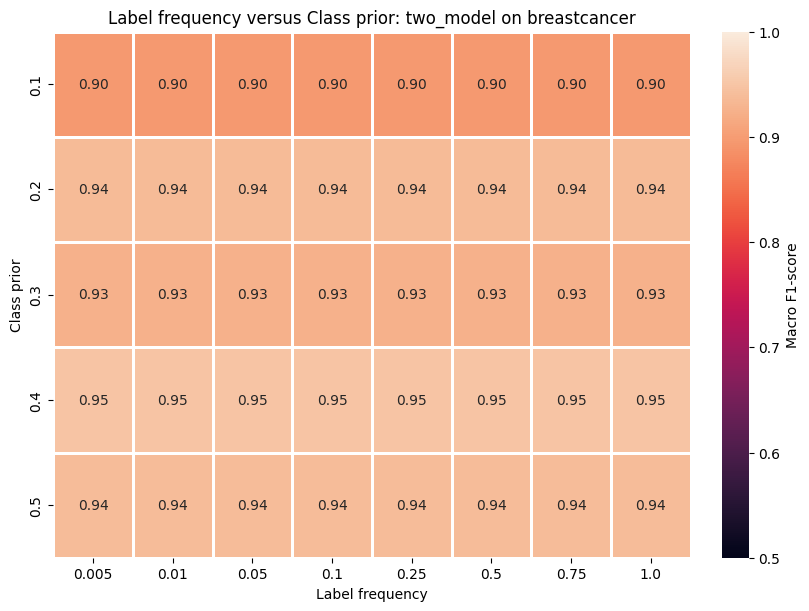

<Figure size 800x600 with 0 Axes>

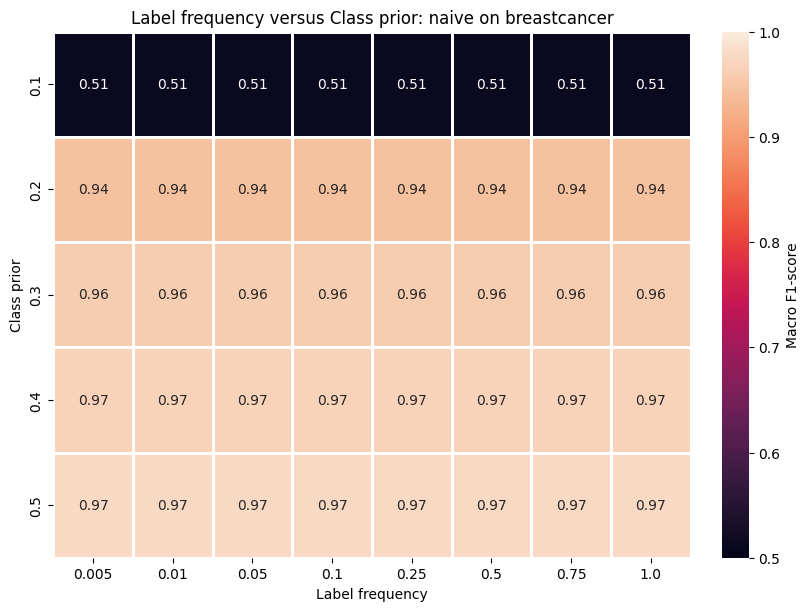

<Figure size 800x600 with 0 Axes>

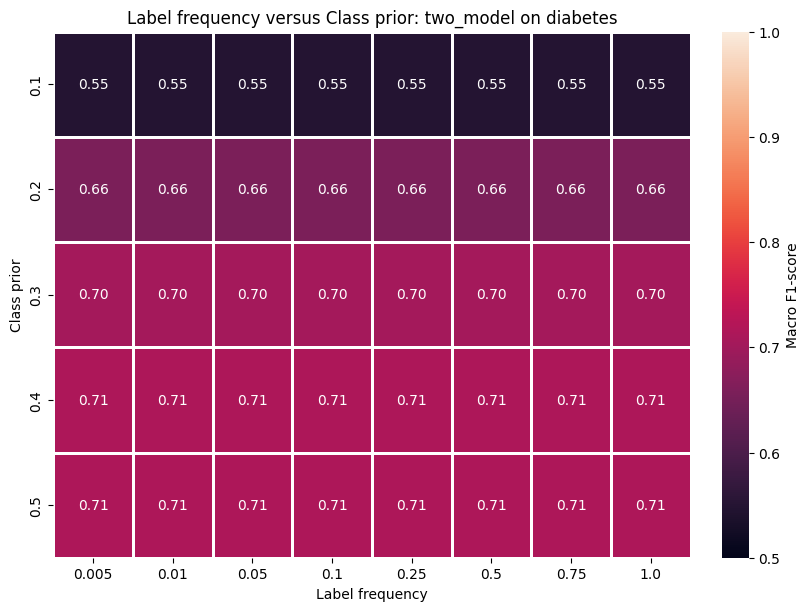

<Figure size 800x600 with 0 Axes>

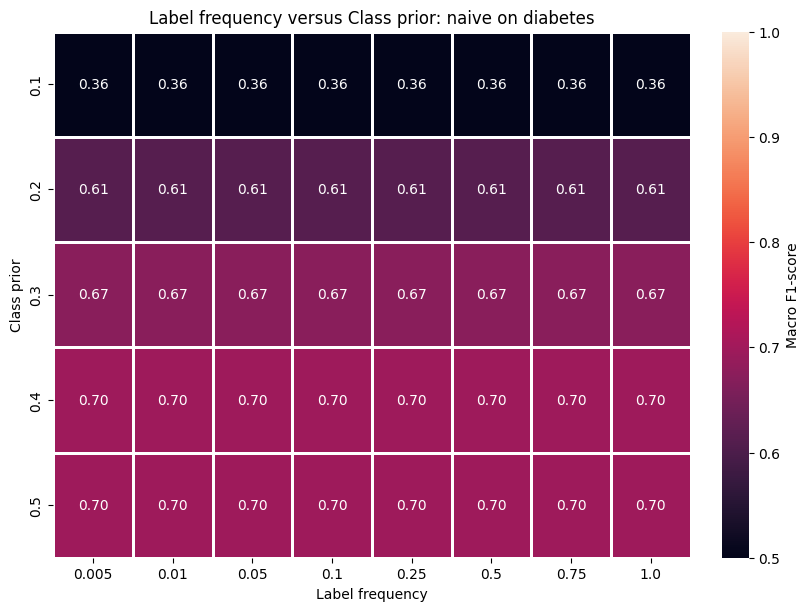

<Figure size 800x600 with 0 Axes>

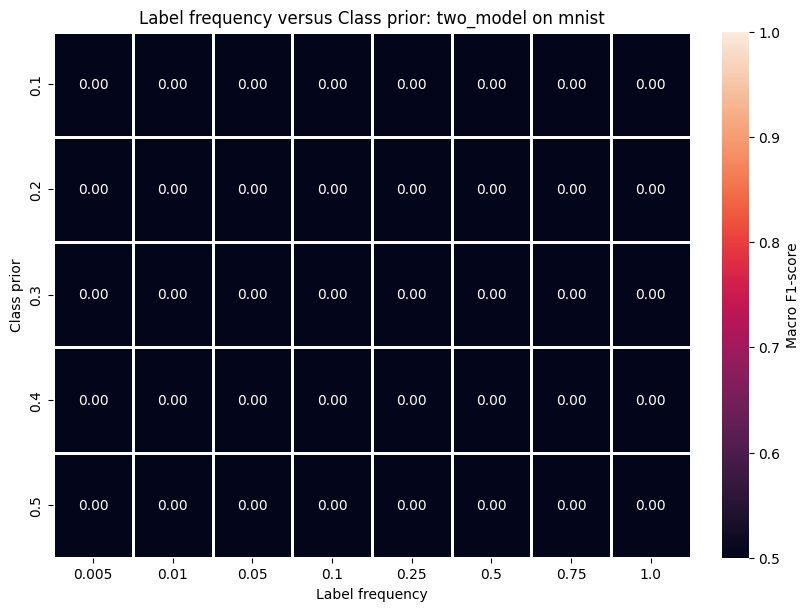

<Figure size 800x600 with 0 Axes>

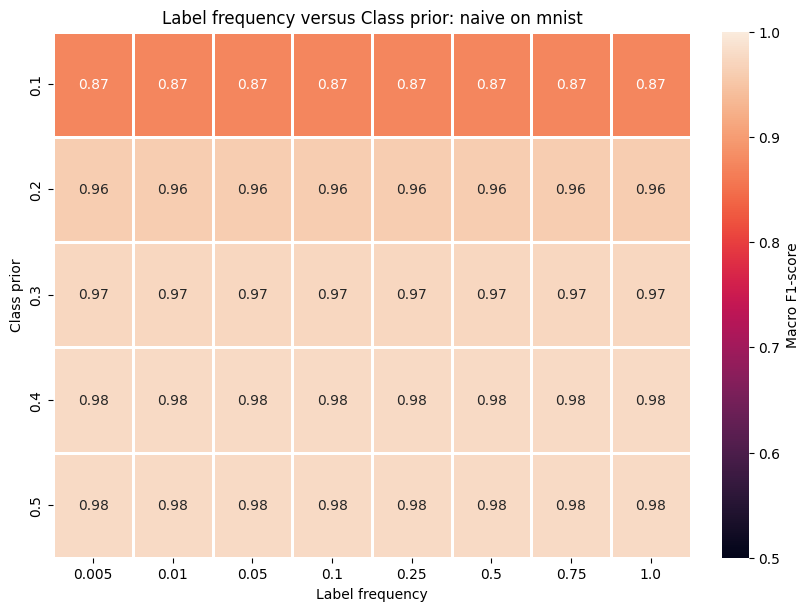

<Figure size 800x600 with 0 Axes>

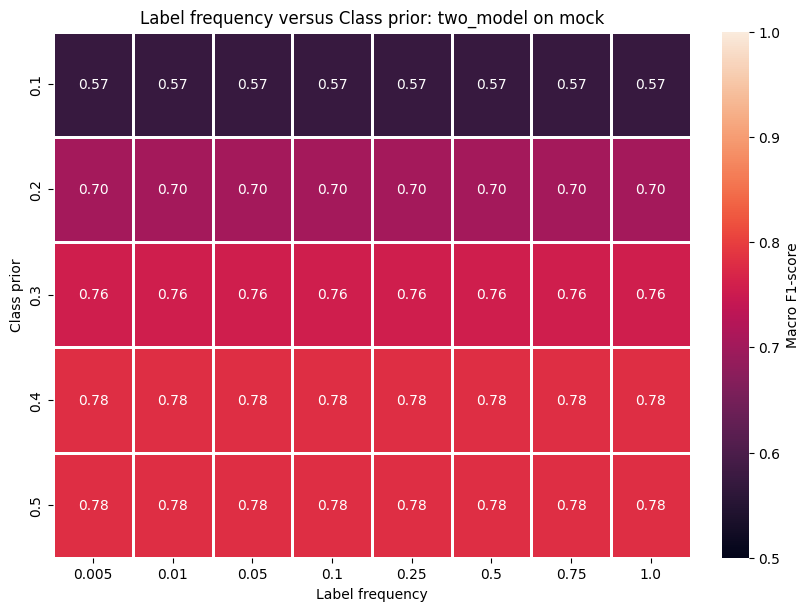

<Figure size 800x600 with 0 Axes>

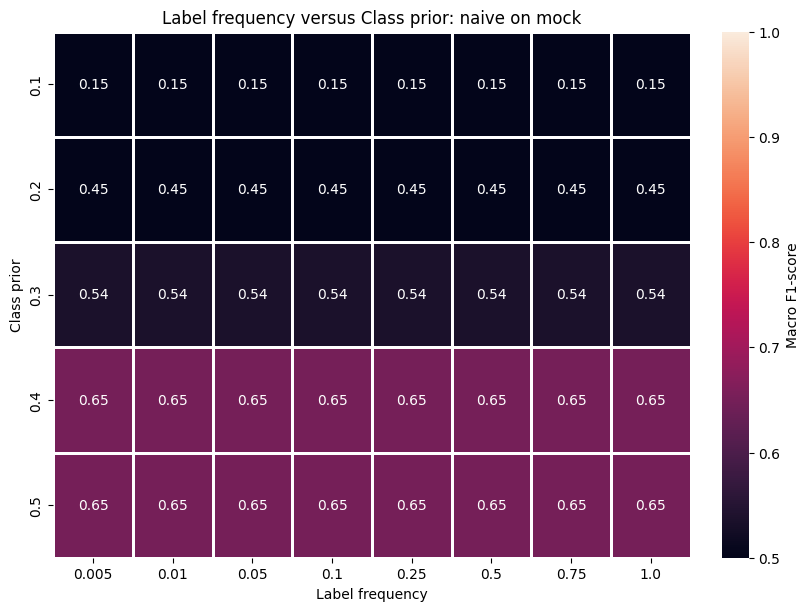

In [18]:
for dataset in data_G["dataset"].unique():
    data = data_G.loc[data_G['dataset']==dataset]
    for model in ["two_model","naive"]:



        fig = plt.figure(figsize=(8, 6),layout='constrained')
        data_m = data.loc[data['model']==model]
        fig = plt.figure(figsize=(8, 6),layout='constrained')
        data_selec = data_m[[VAR_1,VAR_2,"f1"]]
        try:
            pivot = data_selec.pivot_table(index=VAR_1, columns=VAR_2, values="f1")
            plt.title(f"Label frequency versus Class prior: {model} on {dataset}")
            sns.heatmap(
                data=pivot,
                annot=True,
                cbar_kws={"label": "Macro F1-score"},
                linewidths=1,
                fmt=".2f",
                vmin=0.5,
                vmax=1
            )
            plt.xlabel("Label frequency")
            plt.ylabel("Class prior")
            plt.savefig(os.path.join(fig_folder, f"{model}_{dataset}_heatmap_{VAR_1}_vs_{VAR_2}.png"))
            plt.show()
        except Exception as e:
            print(f"Error occurred while plotting heatmap for {model} on {dataset}: {e}")
